In [9]:
%pip install seaborn matplotlib pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


--- TASK 1: Data Cleaning ---
Task 1 Complete: Saved 'Cleaned_Dataset.csv'

--- TASK 2: Movies vs TV Shows ---
type
Movie      6126
TV Show    2664
Name: count, dtype: int64


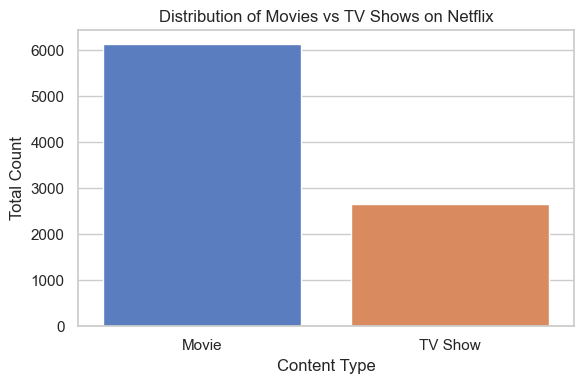

Task 2 Chart Saved: 'Task2_Content_Type_Distribution.png'

--- TASK 3: Top Content Producing Countries ---
country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Canada             271
Japan              259
South Korea        214
France             213
Spain              182
Mexico             138
Name: count, dtype: int64


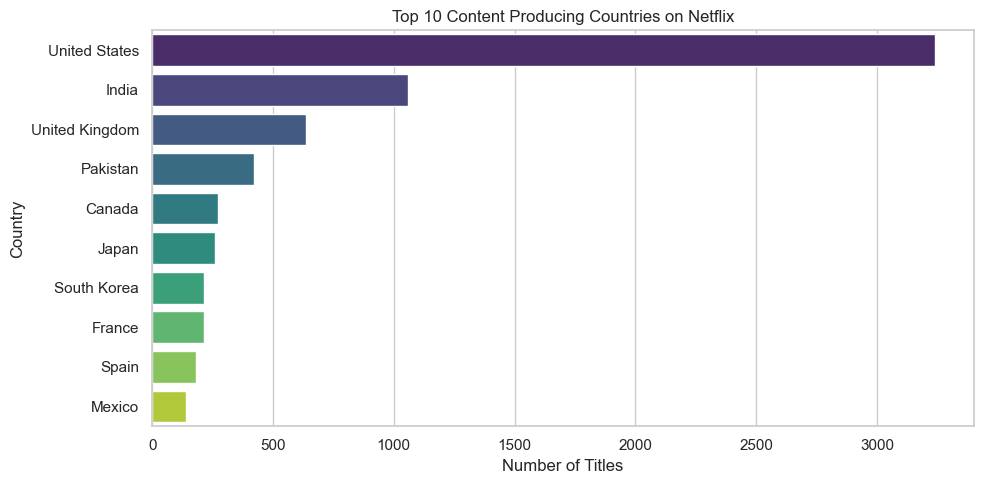

Task 3 Chart Saved: 'Task3_Top_10_Countries.png'

--- TASK 4: Trend Analysis by Release Year ---


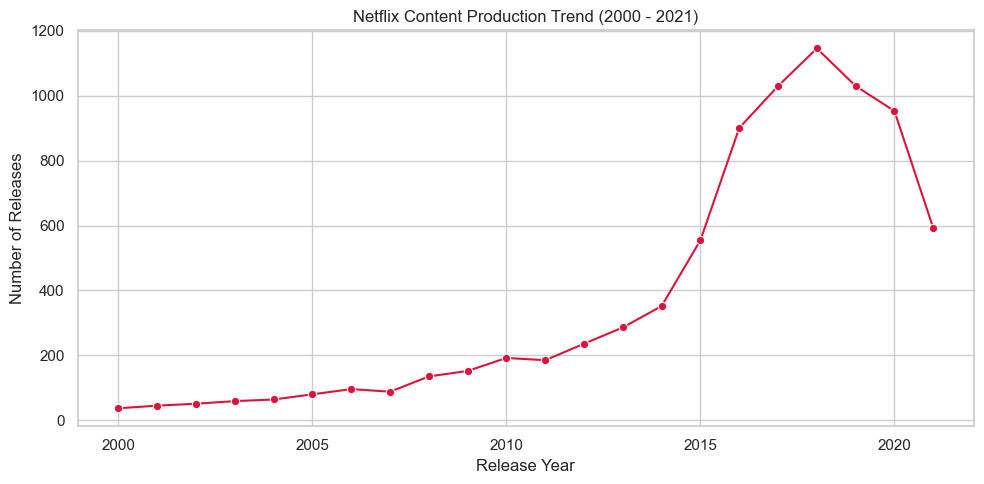

Task 4 Chart Saved: 'Task4_Release_Year_Trends.png'

All 4 tasks completed successfully!


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress minor deprecation warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

# ==========================================
# TASK 1: Data Cleaning & Preparation
# ==========================================
print("--- TASK 1: Data Cleaning ---")
df = pd.read_csv("Dataset.csv")

# Standardize string columns (compatible with newer pandas)
string_cols = df.select_dtypes(include=['object', 'string']).columns
for col in string_cols:
    df[col] = df[col].astype(str).str.strip()

# Convert date_added to datetime format
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year

# Save cleaned dataset
df.to_csv("Cleaned_Dataset.csv", index=False)
print("Task 1 Complete: Saved 'Cleaned_Dataset.csv'\n")


# ==========================================
# TASK 2: Content Type Analysis
# ==========================================
print("--- TASK 2: Movies vs TV Shows ---")
type_counts = df['type'].value_counts()
print(type_counts)

plt.figure(figsize=(6, 4))
sns.barplot(x=type_counts.index, y=type_counts.values, hue=type_counts.index, palette="muted", legend=False)
plt.title("Distribution of Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Total Count")
plt.tight_layout()
plt.savefig("Task2_Content_Type_Distribution.png")
plt.show()
print("Task 2 Chart Saved: 'Task2_Content_Type_Distribution.png'\n")


# ==========================================
# TASK 3: Country-Wise Content Analysis
# ==========================================
print("--- TASK 3: Top Content Producing Countries ---")
country_series = df['country'].replace('Not Given', pd.NA).dropna()
top_countries = country_series.str.split(', ').explode().value_counts().head(10)
print(top_countries)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette="viridis", legend=False)
plt.title("Top 10 Content Producing Countries on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("Task3_Top_10_Countries.png")
plt.show()
print("Task 3 Chart Saved: 'Task3_Top_10_Countries.png'\n")


# ==========================================
# TASK 4: Trend Analysis by Release Year
# ==========================================
print("--- TASK 4: Trend Analysis by Release Year ---")
yearly_trends = df[df['release_year'] >= 2000]['release_year'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.lineplot(x=yearly_trends.index, y=yearly_trends.values, marker="o", color="crimson")
plt.title("Netflix Content Production Trend (2000 - 2021)")
plt.xlabel("Release Year")
plt.ylabel("Number of Releases")
plt.tight_layout()
plt.savefig("Task4_Release_Year_Trends.png")
plt.show()
print("Task 4 Chart Saved: 'Task4_Release_Year_Trends.png'\n")

print("All 4 tasks completed successfully!")